In [1]:
import pandas as pd

train_df = pd.read_csv('/Users/u2017787/Downloads/SnakeClassification/csv/train.csv')
test_df = pd.read_csv('/Users/u2017787/Downloads/SnakeClassification/csv/test.csv')

In [2]:
print(train_df.head())
print(test_df.head())

   Unnamed: 0                binomial                   country  \
0           0  Agkistrodon contortrix  United States of America   
1           1  Agkistrodon contortrix  United States of America   
2           2  Agkistrodon contortrix  United States of America   
3           3  Agkistrodon contortrix  United States of America   
4           4  Agkistrodon contortrix  United States of America   

       continent        genus     family                              UUID  \
0  North America  Agkistrodon  Viperidae  20e23008100d4e249fd757c11fe059fe   
1  North America  Agkistrodon  Viperidae  0c6d14f33f404013ab116ab09880c523   
2  North America  Agkistrodon  Viperidae  3a31a32de0434653b4a82a30806f7a6d   
3  North America  Agkistrodon  Viperidae  1c5a3b2953c84d698fad8a40db91323e   
4  North America  Agkistrodon  Viperidae  e10c99a58c2546dab2c0d998de1f7c1b   

   class_id        snake_sub_family  poisonous         X         Y    height  \
0        18  Agkistrodon contortrix          1  

In [3]:
from pathlib import Path

def get_image_paths_and_labels(df, img_folder):
    img_paths = []
    labels = []
    sub = []
    for _, row in df.iterrows():
        img_path = Path(img_folder) / str(row['class_id']) / f"{row['UUID']}.jpg"
        sub.append(row['snake_sub_family'])
        img_paths.append(img_path)
        labels.append(row['class_id'])
    return img_paths, labels, sub

In [4]:
train_img_paths, train_labels, train_sub_family = get_image_paths_and_labels(train_df, '/Users/u2017787/Downloads/SnakeClassification/train')
test_img_paths, test_labels, test_sub_family = get_image_paths_and_labels(test_df, '/Users/u2017787/Downloads/SnakeClassification/test')

In [5]:
from fastai.data.block import DataBlock
from fastai.vision.all import *

In [6]:
block = DataBlock(
    blocks=(ImageBlock, CategoryBlock),  
    get_x=lambda x: x['image'],  
    get_y=lambda x: x['snake_sub_family'], 
    splitter=ColSplitter(),  
    item_tfms=Resize(224),  
    batch_tfms=aug_transforms()  
)

In [7]:
from sklearn.model_selection import train_test_split

train_data = [(path, sub) for path, label, sub in zip(train_img_paths, train_labels, train_sub_family)]
test_data = [(path, sub) for path, label, sub in zip(test_img_paths, test_labels, test_sub_family)]

train_data, valid_data = train_test_split(train_data, test_size=0.2, stratify=train_labels)

train_df = pd.DataFrame(train_data, columns=["image", "snake_sub_family"])
valid_df = pd.DataFrame(valid_data, columns=["image", "snake_sub_family"])
test_df = pd.DataFrame(test_data, columns=["image", "snake_sub_family"])

train_df['is_valid'] = False
valid_df['is_valid'] = True

full_df = pd.concat([train_df, valid_df], ignore_index=True)

dls = block.dataloaders(full_df, bs=32)

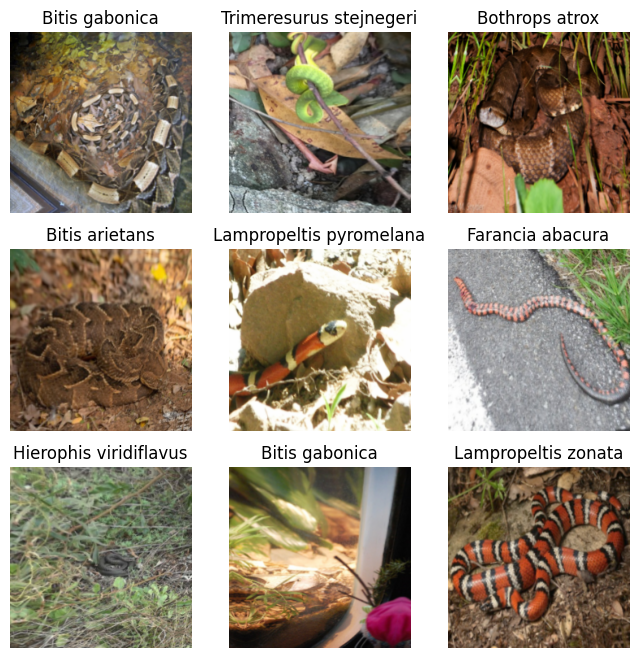

In [8]:
dls.show_batch(max_n=9, figsize=(8,8))

In [9]:
learn = vision_learner(dls, resnet34, metrics=error_rate)

In [ ]:
learn.fit_one_cycle(4)

In [ ]:
learn.save('stage-1')

In [ ]:
learn.unfreeze()

In [ ]:
learn.lr_find()

In [ ]:
learn.load('stage-1')

In [ ]:
learn.fit_one_cycle(2, lr_max=slice(3e-5,3e-4))

In [ ]:
learn.save('stage-2')

In [ ]:
learn.load('stage-2');

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)

In [ ]:
interp.plot_confusion_matrix()

In [ ]:
learn.export()

In [ ]:
defaults.device = torch.device('cpu')

In [ ]:
import random
import matplotlib.pyplot as plt

test_path = Path("/Users/u2017787/Downloads/SnakeClassification/test/576")
test_images = list(test_path.glob('*.jpg'))

rand_img = random.choice(test_images)
img = Image.open(rand_img)
plt.imshow(img)

In [ ]:
learn = torch.load(path/'export.pkl')

In [ ]:
pred_class,pred_idx,outputs = learn.predict(rand_img)
pred_class